In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.utils import to_categorical
from keras.datasets import mnist

(x_tn, y_tn), (x_ts, y_ts) = mnist.load_data()

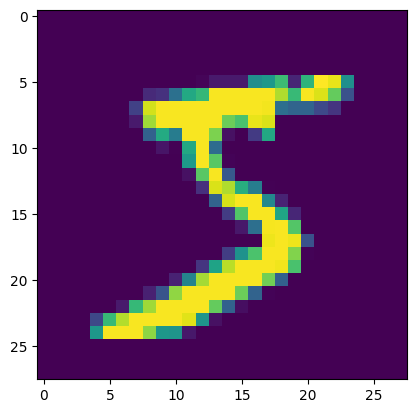

In [2]:
plt.imshow(x_tn[0])

In [3]:
num_px = x_tn.shape[1]*x_tn.shape[2]

x_tn = x_tn.reshape(x_tn.shape[0], num_px).astype('float64')
x_ts = x_ts.reshape(x_ts.shape[0], num_px).astype('float64')

In [4]:
x_tn = x_tn/255
x_ts = x_ts/255

In [5]:
y_tn = to_categorical(y_tn)
y_ts = to_categorical(y_ts)

num_class = y_tn.shape[1]

In [6]:
def classification_model():
    
    model = Sequential()
    model.add(Input(shape=(num_px,)))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(36, activation='relu'))
    model.add(Dense(num_class, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

In [7]:
clx_model = classification_model()

In [11]:
clx_model.fit(x_tn, y_tn, validation_split=0.2, epochs=100, verbose=2, batch_size=86)

Epoch 1/100
559/559 - 2s - 4ms/step - accuracy: 0.9991 - loss: 0.0028 - val_accuracy: 0.9803 - val_loss: 0.1106
Epoch 2/100
559/559 - 1s - 3ms/step - accuracy: 1.0000 - loss: 3.0132e-04 - val_accuracy: 0.9816 - val_loss: 0.1111
Epoch 3/100
559/559 - 1s - 3ms/step - accuracy: 0.9999 - loss: 4.7130e-04 - val_accuracy: 0.9813 - val_loss: 0.1165
Epoch 4/100
559/559 - 1s - 3ms/step - accuracy: 1.0000 - loss: 9.3218e-05 - val_accuracy: 0.9820 - val_loss: 0.1178
Epoch 5/100
559/559 - 1s - 3ms/step - accuracy: 1.0000 - loss: 5.8240e-05 - val_accuracy: 0.9822 - val_loss: 0.1197
Epoch 6/100
559/559 - 1s - 3ms/step - accuracy: 1.0000 - loss: 4.2474e-05 - val_accuracy: 0.9821 - val_loss: 0.1217
Epoch 7/100
559/559 - 1s - 3ms/step - accuracy: 1.0000 - loss: 2.9941e-05 - val_accuracy: 0.9826 - val_loss: 0.1244
Epoch 8/100
559/559 - 1s - 3ms/step - accuracy: 1.0000 - loss: 2.1206e-05 - val_accuracy: 0.9825 - val_loss: 0.1261
Epoch 9/100
559/559 - 1s - 3ms/step - accuracy: 1.0000 - loss: 1.5307e-05 - 

In [13]:
score = clx_model.evaluate(x_ts, y_ts, verbose=2)
clx_model.save('handwriting_classifiier.keras')

313/313 - 0s - 1ms/step - accuracy: 0.9857 - loss: 0.1833


In [18]:
print(score[1],'\n', 1-score[1])

0.9857000112533569 
 0.014299988746643066


In [23]:
def neural_net():
    model = Sequential()
    model.add(Input(shape=(num_px,)))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(24, activation='sigmoid'))
    model.add(Dense(num_class, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [24]:
nn_model = neural_net()

In [25]:
nn_model.fit(x_tn, y_tn, validation_split=0.15, verbose=2, epochs=25)

Epoch 1/25
1594/1594 - 5s - 3ms/step - accuracy: 0.8901 - loss: 0.4662 - val_accuracy: 0.9566 - val_loss: 0.1832
Epoch 2/25
1594/1594 - 3s - 2ms/step - accuracy: 0.9594 - loss: 0.1568 - val_accuracy: 0.9646 - val_loss: 0.1369
Epoch 3/25
1594/1594 - 3s - 2ms/step - accuracy: 0.9723 - loss: 0.1047 - val_accuracy: 0.9719 - val_loss: 0.1133
Epoch 4/25
1594/1594 - 3s - 2ms/step - accuracy: 0.9775 - loss: 0.0828 - val_accuracy: 0.9733 - val_loss: 0.1002
Epoch 5/25
1594/1594 - 3s - 2ms/step - accuracy: 0.9812 - loss: 0.0681 - val_accuracy: 0.9702 - val_loss: 0.1124
Epoch 6/25
1594/1594 - 3s - 2ms/step - accuracy: 0.9835 - loss: 0.0612 - val_accuracy: 0.9767 - val_loss: 0.0945
Epoch 7/25
1594/1594 - 3s - 2ms/step - accuracy: 0.9863 - loss: 0.0510 - val_accuracy: 0.9741 - val_loss: 0.0992
Epoch 8/25
1594/1594 - 3s - 2ms/step - accuracy: 0.9879 - loss: 0.0453 - val_accuracy: 0.9758 - val_loss: 0.1060
Epoch 9/25
1594/1594 - 3s - 2ms/step - accuracy: 0.9883 - loss: 0.0431 - val_accuracy: 0.9791 - 

[<Dense name=dense_11, built=True>,
 <Dense name=dense_12, built=True>,
 <Dense name=dense_13, built=True>,
 <Dense name=dense_14, built=True>,
 <Dense name=dense_15, built=True>,
 <Dense name=dense_16, built=True>,
 <Dense name=dense_17, built=True>]

In [29]:
score = nn_model.evaluate(x_ts, y_ts, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9752 - loss: 0.1146


In [34]:
score

[0.1146283820271492, 0.9751999974250793]

In [35]:
pt_model = keras.saving.load_model('handwriting_classifiier.keras')

In [36]:
pt_model.fit(x_tn, y_tn, validation_split=.8, epochs=10, verbose=2, batch_size=100)

Epoch 1/10
120/120 - 2s - 15ms/step - accuracy: 1.0000 - loss: 1.4902e-10 - val_accuracy: 0.9957 - val_loss: 0.0563
Epoch 2/10
120/120 - 1s - 8ms/step - accuracy: 1.0000 - loss: 6.9545e-11 - val_accuracy: 0.9957 - val_loss: 0.0563
Epoch 3/10
120/120 - 1s - 8ms/step - accuracy: 1.0000 - loss: 7.9479e-11 - val_accuracy: 0.9957 - val_loss: 0.0563
Epoch 4/10
120/120 - 1s - 8ms/step - accuracy: 1.0000 - loss: 4.9675e-11 - val_accuracy: 0.9957 - val_loss: 0.0563
Epoch 5/10
120/120 - 1s - 8ms/step - accuracy: 1.0000 - loss: 5.9610e-11 - val_accuracy: 0.9957 - val_loss: 0.0563
Epoch 6/10
120/120 - 1s - 8ms/step - accuracy: 1.0000 - loss: 4.9675e-11 - val_accuracy: 0.9957 - val_loss: 0.0563
Epoch 7/10
120/120 - 1s - 8ms/step - accuracy: 1.0000 - loss: 3.9740e-11 - val_accuracy: 0.9958 - val_loss: 0.0564
Epoch 8/10
120/120 - 1s - 8ms/step - accuracy: 1.0000 - loss: 6.9545e-11 - val_accuracy: 0.9958 - val_loss: 0.0564
Epoch 9/10
120/120 - 1s - 8ms/step - accuracy: 1.0000 - loss: 5.9610e-11 - val_

In [37]:
score = pt_model.evaluate(x_ts, y_ts, verbose=2)

313/313 - 0s - 1ms/step - accuracy: 0.9857 - loss: 0.1836


In [38]:
score

[0.18358610570430756, 0.9857000112533569]